In [1]:
#pick one

import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import mat73
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import ttest_rel
from itertools import chain
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)
from GLM_regression import *
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})




datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename_SST = "SSTindivsomata_GLM"
filepath_SST = os.path.join(datasets_dir, filename_SST+".mat")


datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename_NDNF = "NDNFindivsomata_GLM"
filepath_NDNF = os.path.join(datasets_dir, filename_NDNF+".mat")


datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename_EC = "EC_GLM"
filepath_EC = os.path.join(datasets_dir, filename_EC+".mat")


In [37]:
print(variable_list)

['Activity', 'Licks', 'Reward_loc', 'Velocity', '#1', '#2', '#3', '#4', '#5', '#6', '#7', '#8', '#9', '#10']


In [38]:
datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename = "SSTindivsomata_GLM"
filepath = os.path.join(datasets_dir, filename+".mat")
reorganized_data_SST, variable_list = preprocess_data(filepath, normalize=True)

avg_residuals_SST_velocity, GLM_params, residual_activity_velocity_SST, vel_predicted_activity_SST_list = compute_variable_subtracted_residuals(reorganized_data_SST, variable_list, ["Velocity"], quintile=None)
avg_residuals_SST_position, GLM_params, residual_activity_position_SST, position_predicted_activity_SST_list = compute_variable_subtracted_residuals(reorganized_data_SST, variable_list, ['#1', '#2', '#3', '#4', '#5', '#6', '#7', '#8', '#9', '#10'], quintile=None)
# avg_residuals, GLM_params, residual_activity_vl_SST = compute_variable_subtracted_residuals(reorganized_data_SST, variable_list, ["Velocity", "Licks"], quintile=None)
# avg_residuals, GLM_params, residual_activity_vr_SST = compute_variable_subtracted_residuals(reorganized_data_SST, variable_list, ["Velocity", "Reward_loc"], quintile=None)
# avg_residuals, GLM_params, residual_activity_vrl_SST = compute_variable_subtracted_residuals(reorganized_data_SST, variable_list, ["Velocity", "Reward_loc", "Licks"], quintile=None)


datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename = "NDNFindivsomata_GLM"
filepath = os.path.join(datasets_dir, filename+".mat")
reorganized_data_NDNF, variable_list = preprocess_data(filepath, normalize=True)

avg_residuals_NDNF_velocity, GLM_params, residual_activity_velocity_NDNF, vel_predicted_activity_NDNF_list = compute_variable_subtracted_residuals(reorganized_data_NDNF, variable_list, ["Velocity"], quintile=None)
# avg_residuals, GLM_params, residual_activity_vl_NDNF = compute_variable_subtracted_residuals(reorganized_data_NDNF, variable_list, ["Velocity", "Licks"], quintile=None)
# avg_residuals, GLM_params, residual_activity_vr_NDNF = compute_variable_subtracted_residuals(reorganized_data_NDNF, variable_list, ["Velocity", "Reward_loc"], quintile=None)
# avg_residuals, GLM_params, residual_activity_vrl_NDNF = compute_variable_subtracted_residuals(reorganized_data_NDNF, variable_list, ["Velocity", "Reward_loc", "Licks"], quintile=None)

datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename = "EC_GLM"
filepath = os.path.join(datasets_dir, filename+".mat")
reorganized_data_EC, variable_list = preprocess_data(filepath, normalize=True)

avg_residuals_EC_velocity, GLM_params, residual_activity_velocity_EC, vel_predicted_activity_EC_list = compute_variable_subtracted_residuals(reorganized_data_EC, variable_list, ["Velocity"], quintile=None)
# avg_residuals, GLM_params, residual_activity_vl_EC = compute_variable_subtracted_residuals(reorganized_data_EC, variable_list, ["Velocity", "Licks"], quintile=None)
# avg_residuals, GLM_params, residual_activity_vr_EC = compute_variable_subtracted_residuals(reorganized_data_EC, variable_list, ["Velocity", "Reward_loc"], quintile=None)
# avg_residuals, GLM_params, residual_activity_vrl_EC = compute_variable_subtracted_residuals(reorganized_data_EC, variable_list, ["Velocity", "Reward_loc", "Licks"], quintile=None)


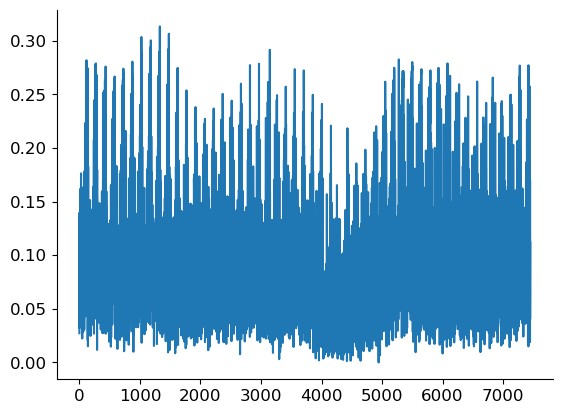

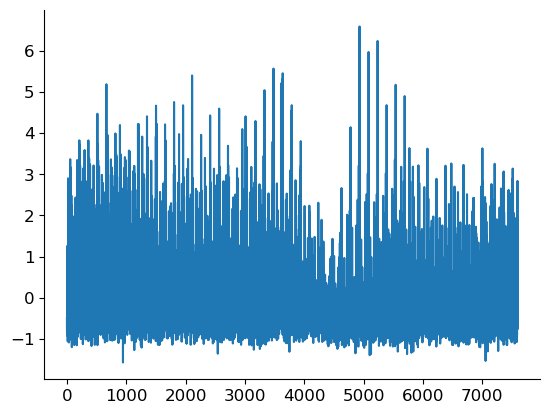

In [22]:

# flattened_vel_predicted_activity_SST = np.array(vel_predicted_activity_SST)
# flattened_vel_predicted_activity_SST = flattened_vel_predicted_activity_SST.flatten()


    
plt.figure()
plt.plot(flattened_vel_predict_list[74])
plt.show()

plt.figure()
plt.plot(flattened_vel_list[9])
plt.show()

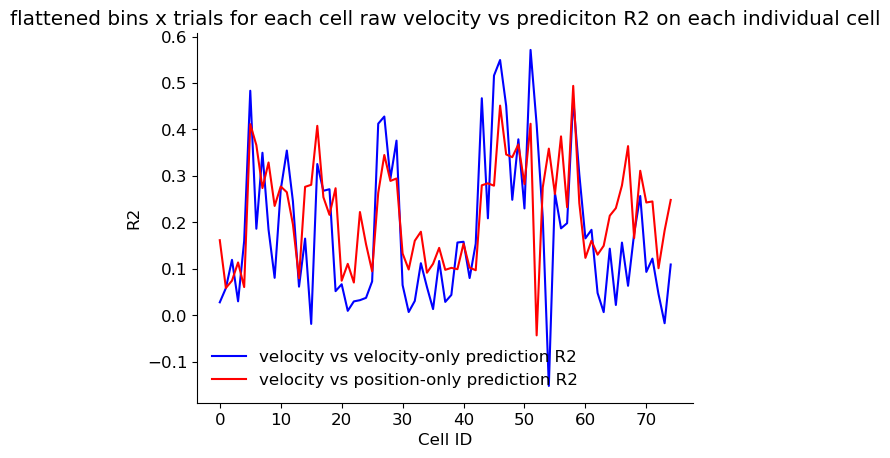

In [56]:

correlation_values_vel = []
for pred, actual in zip(flattened_vel_predict_list, flattened_vel_list):
    corr = np.corrcoef(pred, actual)[0, 1] 
    correlation_values_vel.append(corr)

correlation_values_position = []
for pred, actual in zip(flattened_position_predict_list, flattened_vel_list):
    corr = np.corrcoef(pred, actual)[0, 1] 
    correlation_values_position.append(corr)
    
plt.figure()
plt.plot(correlation_values_vel, color='b', label="velocity vs velocity-only prediction R2")
plt.plot(correlation_values_position, color='r', label="velocity vs position-only prediction R2")
plt.legend()
plt.ylabel("R2")
plt.xlabel("Cell ID")
plt.title("flattened bins x trials for each cell raw velocity vs prediciton R2 on each individual cell")
plt.show()


75


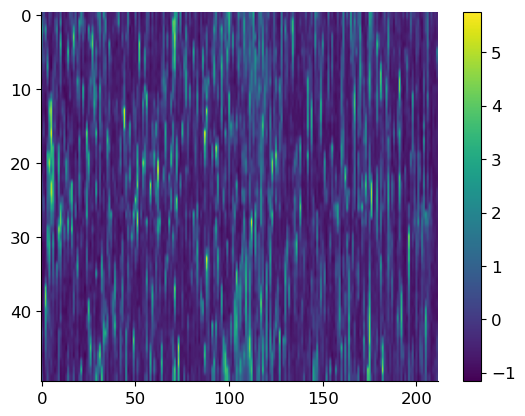

In [86]:
print(len(velocity_list))
list_of_2d_velocities = [np.vstack(arrays) for arrays in velocity_list]
plt.imshow(list_of_2d_velocities[1], aspect='auto')
plt.colorbar()
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


10600


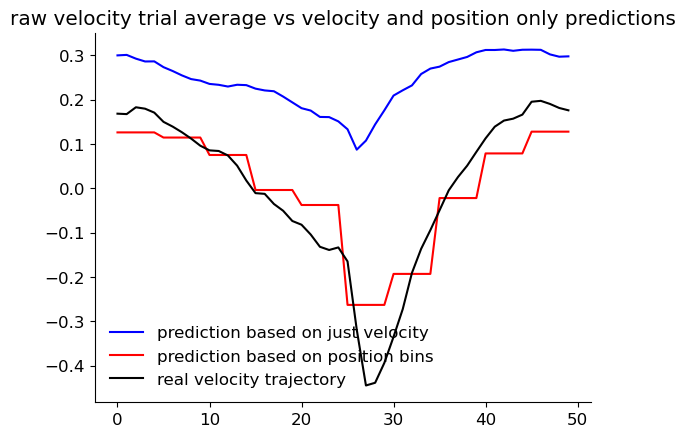

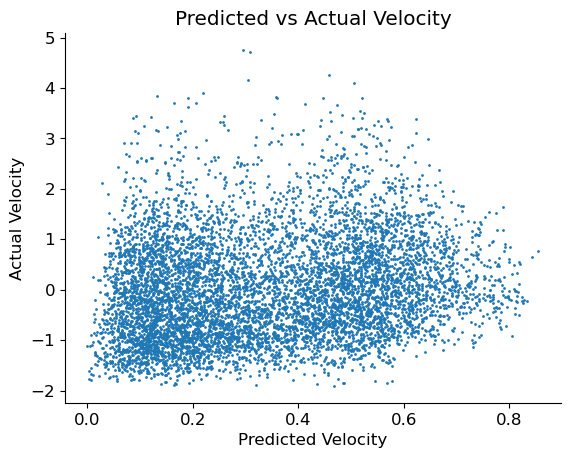

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


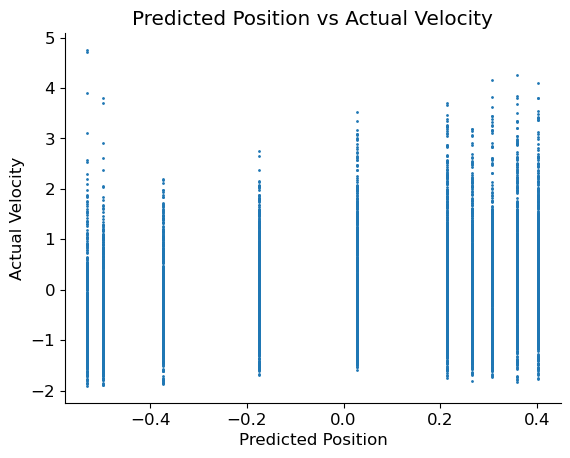

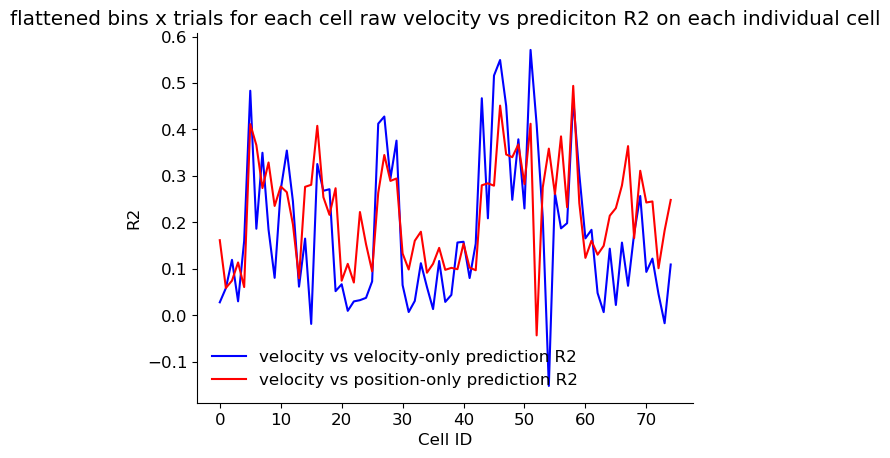

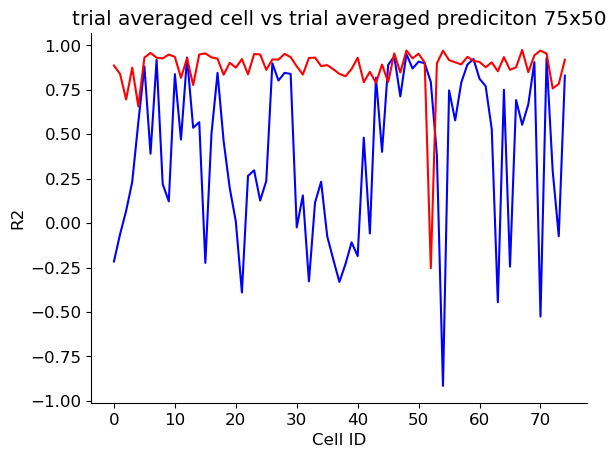

In [94]:
### prediction 
trial_av_prediction_list = []
flattened_vel_predict_list = []
for i in vel_predicted_activity_SST:
    flattened_vel_predict_list.append(i.flatten())
    trial_av_prediction_list.append(np.mean(i, axis=1))
    
trial_av_prediction_list_position = []
flattened_position_predict_list = []
for i in position_predicted_activity_SST_list:
    flattened_position_predict_list.append(i.flatten())
    trial_av_prediction_list_position.append(np.mean(i, axis=1))


    
###### actual    
velocity_list = []
for animal, subdict in reorganized_data_SST.items():
        for cell, value in subdict.items():
            neuron_data = reorganized_data_SST[animal][cell]
            velocity = neuron_data[:, 0, :]
            velocity_list.append(velocity)

trial_av_vel_list = []
flattened_vel_list = []
for i in velocity_list:
    flattened_vel_list.append(i.flatten())
    trial_av_vel_list.append(np.mean(i, axis=1))
    
    
    

print(len(flattened_position_predict_list[1]))
    

# trial_av_prediction_list = np.vstack(trial_av_prediction_list)
# trial_av_vel_list = np.vstack(trial_av_vel_list)
# trial_av_prediction_list_position = np.vstack(trial_av_prediction_list_position)


plt.figure()
plt.plot(np.mean(trial_av_prediction_list, axis=0), color='b', label='prediction based on just velocity')
plt.plot(np.mean(trial_av_prediction_list_position, axis=0), color='r', label='prediction based on position bins')
plt.plot(np.mean(trial_av_vel_list, axis=0), color='k', label='real velocity trajectory')
plt.title("raw velocity trial average vs velocity and position only predictions")
plt.legend()
plt.show






plt.figure()
plt.plot(flattened_vel_predict_list[8], flattened_vel_list[8], '.', markersize=2)  
plt.xlabel('Predicted Velocity')  
plt.ylabel('Actual Velocity')    
plt.title('Predicted vs Actual Velocity')
plt.legend()
plt.show()

plt.figure()
plt.plot(flattened_position_predict_list[8], flattened_vel_list[8], '.', markersize=2)  
plt.xlabel('Predicted Position')  
plt.ylabel('Actual Velocity')    
plt.title('Predicted Position vs Actual Velocity')
plt.legend()
plt.show()




correlation_values_vel = []
for pred, actual in zip(flattened_vel_predict_list, flattened_vel_list):
    corr = np.corrcoef(pred, actual)[0, 1] 
    correlation_values_vel.append(corr)

correlation_values_position = []
for pred, actual in zip(flattened_position_predict_list, flattened_vel_list):
    corr = np.corrcoef(pred, actual)[0, 1] 
    correlation_values_position.append(corr)
    
plt.figure()
plt.plot(correlation_values_vel, color='b', label="velocity vs velocity-only prediction R2")
plt.plot(correlation_values_position, color='r', label="velocity vs position-only prediction R2")
plt.legend()
plt.ylabel("R2")
plt.xlabel("Cell ID")
plt.title("flattened bins x trials for each cell raw velocity vs prediciton R2 on each individual cell")
plt.show()

    
correlation_values_trial_av_vel = []
for pred, actual in zip(trial_av_prediction_list, trial_av_vel_list):
    corr = np.corrcoef(pred, actual)[0, 1] 
    correlation_values_trial_av_vel.append(corr)
    
correlation_values_trial_av_prediction = []
for pred, actual in zip(trial_av_prediction_list_position, trial_av_vel_list):
    corr = np.corrcoef(pred, actual)[0, 1] 
    correlation_values_trial_av_prediction.append(corr)
    
    
plt.figure()
plt.plot(correlation_values_trial_av_vel, color='b', label='trial av raw vs velocity prediction')
plt.plot(correlation_values_trial_av_prediction, color='r', label='trial av raw vs position prediction')
plt.ylabel("R2")
plt.xlabel("Cell ID")
plt.title("trial averaged cell vs trial averaged prediciton 75x50")
plt.show()



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


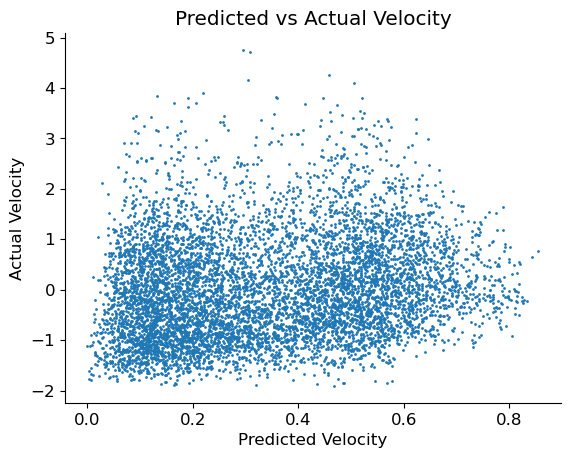

In [93]:
plt.figure()
plt.plot(flattened_vel_predict_list[8], flattened_vel_list[8], '.', markersize=2)  
plt.xlabel('Predicted Velocity')  
plt.ylabel('Actual Velocity')    
plt.title('Predicted vs Actual Velocity')
plt.legend()
plt.show()



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


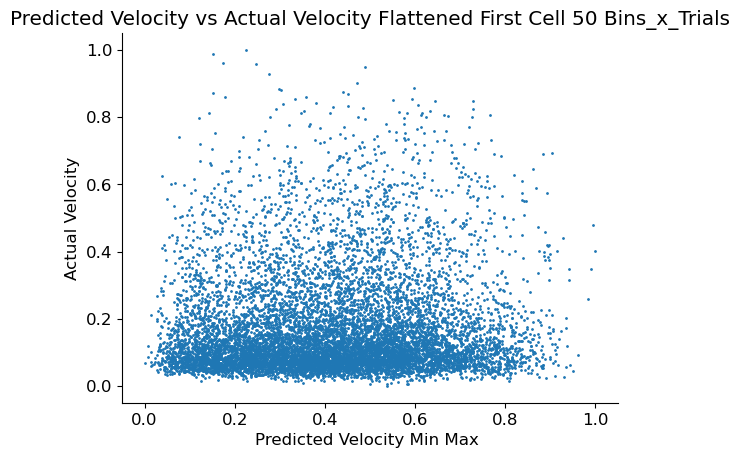

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


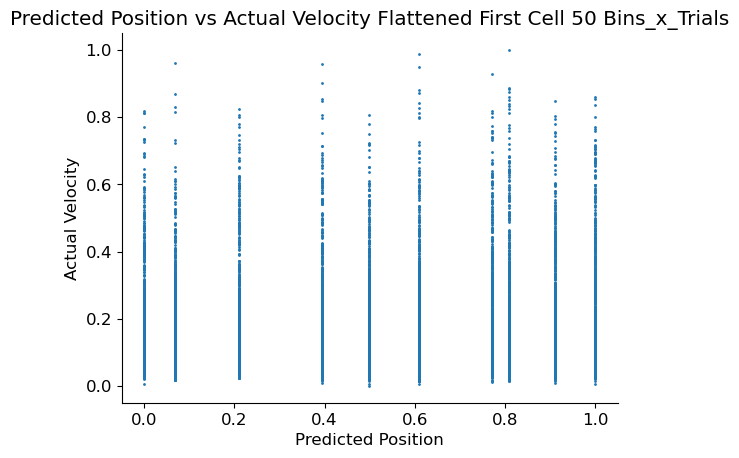

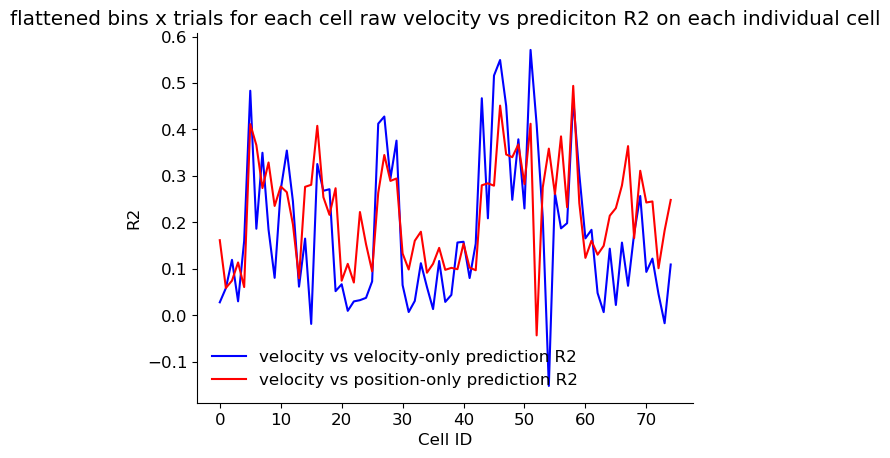

In [76]:

flattened_vel_predict_list = []
for i in vel_predicted_activity_SST:
    flattened_vel_predict_list.append(i.flatten())
    
flattened_position_predict_list = []
for i in position_predicted_activity_SST_list:
    flattened_position_predict_list.append(i.flatten())

    
###### actual    
velocity_list = []
for animal, subdict in reorganized_data_SST.items():
        for cell, value in subdict.items():
            neuron_data = reorganized_data_SST[animal][cell]
            velocity = neuron_data[:, 0, :]
            velocity_list.append(velocity)

flattened_vel_list = []
for i in velocity_list:
    flattened_vel_list.append(i.flatten())

    

min_maxed_flattened_velocity = []
for cell in flattened_vel_list:
    normed = []
    for trials in cell:
        norm_bin = (trials - np.min(cell)) / (np.max(cell) - np.min(cell))
        normed.append(norm_bin)
    min_maxed_flattened_velocity.append(normed)
        
    
min_maxed_flattened_velocity_prediction = []
for cell in flattened_vel_predict_list:
    normed = []
    for trials in cell:
        norm_bin = (trials - np.min(cell)) / (np.max(cell) - np.min(cell))
        normed.append(norm_bin)
    min_maxed_flattened_velocity_prediction.append(normed)
        


min_maxed_flattened_position_prediction = []
for cell in flattened_position_predict_list:
    normed = []
    for trials in cell:
        norm_bin = (trials - np.min(cell)) / (np.max(cell) - np.min(cell))
        normed.append(norm_bin)
    min_maxed_flattened_position_prediction.append(normed)
        



plt.figure()
plt.plot(min_maxed_flattened_velocity_prediction[1], min_maxed_flattened_velocity[1], '.', markersize=2)  
plt.xlabel('Predicted Velocity Min Max ')  
plt.ylabel('Actual Velocity')    
plt.title('Predicted Velocity vs Actual Velocity Flattened First Cell 50 Bins_x_Trials')
plt.legend()
plt.show()

plt.figure()
plt.plot(min_maxed_flattened_position_prediction[1], min_maxed_flattened_velocity[1], '.', markersize=2)  
plt.xlabel('Predicted Position')  
plt.ylabel('Actual Velocity')    
plt.title('Predicted Position vs Actual Velocity Flattened First Cell 50 Bins_x_Trials')
plt.legend()
plt.show()




correlation_values_vel = []
for pred, actual in zip(min_maxed_flattened_velocity_prediction, min_maxed_flattened_velocity):
    corr = np.corrcoef(pred, actual)[0, 1] 
    correlation_values_vel.append(corr)

correlation_values_position = []
for pred, actual in zip(min_maxed_flattened_position_prediction, min_maxed_flattened_velocity):
    corr = np.corrcoef(pred, actual)[0, 1] 
    correlation_values_position.append(corr)
    
plt.figure()
plt.plot(correlation_values_vel, color='b', label="velocity vs velocity-only prediction R2")
plt.plot(correlation_values_position, color='r', label="velocity vs position-only prediction R2")
plt.legend()
plt.ylabel("R2")
plt.xlabel("Cell ID")
plt.title("flattened bins x trials for each cell raw velocity vs prediciton R2 on each individual cell")
plt.show()

    
# correlation_values_trial_av_vel = []
# for pred, actual in zip(trial_av_prediction_list, trial_av_vel_list):
#     corr = np.corrcoef(pred, actual)[0, 1] 
#     correlation_values_trial_av_vel.append(corr)
    
# correlation_values_trial_av_prediction = []
# for pred, actual in zip(trial_av_prediction_list_position, trial_av_vel_list):
#     corr = np.corrcoef(pred, actual)[0, 1] 
#     correlation_values_trial_av_prediction.append(corr)
    
    
# plt.figure()
# plt.plot(correlation_values_trial_av_vel, color='b', label='trial av raw vs velocity prediction')
# plt.plot(correlation_values_trial_av_prediction, color='r', label='trial av raw vs position prediction')
# plt.ylabel("R2")
# plt.xlabel("Cell ID")
# plt.title("trial averaged cell vs trial averaged prediciton 75x50")
# plt.show()



In [65]:
def get_min_maxed_residuals_argmin_argmax_selectivity(avg_residuals):
    argmax_list = []
    argmin_list = []
    positive_selectivity_list = []
    negative_selectivity_list = []
    normalized_average_residuals_min_max = []
    
    for cell in avg_residuals:
        positive_normalized_cell = []
        negative_normalized_cell = []
        for bins in cell:
            norm_bin = (bins - np.min(cell)) / (np.max(cell) - np.min(cell))
            positive_normalized_cell.append(norm_bin)
            
            norm_bin_negative = np.absolute(1-norm_bin)
            negative_normalized_cell.append(norm_bin_negative)
        
        positive_array = np.array(positive_normalized_cell)
        positive_selectivity = Vinje2000(positive_array, norm='None')
        positive_selectivity_list.append(positive_selectivity)
        
        negative_array = np.array(negative_normalized_cell)
        negative_selectivity = Vinje2000(negative_array, norm='None')
        negative_selectivity_list.append(negative_selectivity)
        normalized_average_residuals_min_max.append(positive_normalized_cell)
        argmax_list.append(np.argmax(cell))
        argmin_list.append(np.argmin(cell))

    avg_residuals_min_max = np.vstack(normalized_average_residuals_min_max)
    positive_selectivity = np.vstack(positive_selectivity_list)
    negative_selectivity = np.vstack(negative_selectivity_list)
    
    is_array = isinstance(positive_selectivity[0], np.ndarray)
    if is_array:
        positive_selectivity = list(chain.from_iterable(positive_selectivity))
        negative_selectivity = list(chain.from_iterable(negative_selectivity))

    return avg_residuals_min_max, argmax_list, argmin_list, positive_selectivity, negative_selectivity

In [66]:
def get_min_maxed_raw_argmin_argmax_selectivity(reorganized_data):
    argmax_list = []
    argmin_list = []
    positive_selectivity_list = []
    negative_selectivity_list = []
    normalized_average_residuals_min_max = []
    
    trial_av_list_raw = []

    for animal, subdict in reorganized_data.items():
        for cell, value in subdict.items():
            neuron_data = reorganized_data[animal][cell]
            neuron_activity = neuron_data[:, 0, :]
            neuron_activity_trial_averaged = np.mean(neuron_activity, axis=1)
            trial_av_list_raw.append(neuron_activity_trial_averaged)
    
    for cell in trial_av_list_raw:
        positive_normalized_cell = []
        negative_normalized_cell = []
        for bins in cell:
            norm_bin = (bins - np.min(cell)) / (np.max(cell) - np.min(cell))
            positive_normalized_cell.append(norm_bin)
            
            norm_bin_negative = np.absolute(1-norm_bin)
            negative_normalized_cell.append(norm_bin_negative)
        
        positive_array = np.array(positive_normalized_cell)
        positive_selectivity = Vinje2000(positive_array, norm='None')
        positive_selectivity_list.append(positive_selectivity)
        
        negative_array = np.array(negative_normalized_cell)
        negative_selectivity = Vinje2000(negative_array, norm='None')
        negative_selectivity_list.append(negative_selectivity)
        normalized_average_residuals_min_max.append(positive_normalized_cell)
        argmax_list.append(np.argmax(cell))
        argmin_list.append(np.argmin(cell))

    avg_residuals_min_max = np.vstack(normalized_average_residuals_min_max)
    positive_selectivity = np.vstack(positive_selectivity_list)
    negative_selectivity = np.vstack(negative_selectivity_list)
    
 

    is_array = isinstance(positive_selectivity[0], np.ndarray)
    if is_array:
        positive_selectivity = list(chain.from_iterable(positive_selectivity))
        negative_selectivity = list(chain.from_iterable(negative_selectivity))
 

    return avg_residuals_min_max, argmax_list, argmin_list, positive_selectivity, negative_selectivity

In [67]:
avg_min_max_SST_raw, argmax_list_SST_raw, argmin_list_SST_raw, positive_selectivity_SST_raw, negative_selectivity_SST_raw = get_min_maxed_raw_argmin_argmax_selectivity(reorganized_data_SST)
avg_min_max_NDNF_raw, argmax_list_NDNF_raw, argmin_list_NDNF_raw, positive_selectivity_NDNF_raw, negative_selectivity_NDNF_raw = get_min_maxed_raw_argmin_argmax_selectivity(reorganized_data_NDNF)
avg_min_max_EC_raw, argmax_list_EC_raw, argmin_list_EC_raw, positive_selectivity_EC_raw, negative_selectivity_EC_raw = get_min_maxed_raw_argmin_argmax_selectivity(reorganized_data_EC)


avg_residuals_min_max_SST_velocity, argmax_list_SST_velocity, argmin_list_SST_velocity, positive_selectivity_SST_velocity, negative_selectivity_SST_velocity = get_min_maxed_residuals_argmin_argmax_selectivity(avg_residuals_SST_velocity)
avg_residuals_min_max_NDNF_velocity, argmax_list_NDNF_velocity, argmin_list_NDNF_velocity, positive_selectivity_NDNF_velocity, negative_selectivity_NDNF_velocity = get_min_maxed_residuals_argmin_argmax_selectivity(avg_residuals_NDNF_velocity)
avg_residuals_min_max_EC_velocity, argmax_list_EC_velocity, argmin_list_EC_velocity, positive_selectivity_EC_velocity, negative_selectivity_EC_velocity = get_min_maxed_residuals_argmin_argmax_selectivity(avg_residuals_EC_velocity)

In [68]:
print(positive_selectivity_SST_velocity)

[0.15003704394347428, 0.2999985531790685, 0.11838373911521351, 0.1397463724814466, 0.17884650816496123, 0.2082474321304228, 0.22735527766900135, 0.18509671464028937, 0.22914697936747966, 0.2986794813493639, 0.11136150952303484, 0.2934771381496802, 0.09547201277757408, 0.18327788433762948, 0.12269874218526472, 0.2797552072729435, 0.2692350245745255, 0.1133772959626196, 0.2772542275248423, 0.2510599219735919, 0.16661327109619417, 0.2045593640880293, 0.32443072986103516, 0.40034960747681086, 0.23206060609122134, 0.20927081254586094, 0.12781150032424124, 0.38833706938435764, 0.22159218016349835, 0.19574198619511624, 0.13322020440058863, 0.1117680589676722, 0.1897672379525522, 0.2216118791782768, 0.1898819666543244, 0.14062721574446285, 0.20383780794644527, 0.18659375812239773, 0.14468919447212628, 0.16270607400399692, 0.18724263446958997, 0.28427884288217353, 0.16920540035001555, 0.18035389898587179, 0.37037194484034797, 0.22383039210110706, 0.2837787504776319, 0.23322969648380476, 0.15029

In [6]:
def get_trial_averaged_raw_data(reorganized_data_group):
    
    trial_av_group_raw = []
    animal_ID_list = []

    for animal, subdict in reorganized_data_group.items():
        for cell, value in subdict.items():
            neuron_data = reorganized_data_group[animal][cell]
            neuron_data = neuron_data[:, 0, :]
            trial_averaged = np.mean(neuron_data, axis=1)
            trial_av_group_raw.append(trial_averaged)
            animal_ID_list.append(animal)

    trial_av_group_raw = np.vstack(trial_av_group_raw)   
    
    
    return trial_av_group_raw, animal_ID_list
    

SST_raw, animal_ID_list_SST = get_trial_averaged_raw_data(reorganized_data_SST)
SST_raw, animal_ID_list_NDNF = get_trial_averaged_raw_data(reorganized_data_NDNF)
SST_raw, animal_ID_list_EC = get_trial_averaged_raw_data(reorganized_data_EC)

def sort_metric_and_animals(metric, animal_ID_list):
    flattened_metric = metric.flatten()
    sorted_metric= np.argsort(flattened_metric)
   
    animal_ID_list = np.array(animal_ID_list)
    animal_ID_sorted = animal_ID_list[sorted_metric]
    
    return sorted_metric, animal_ID_sorted

sorted_positive_selectivity_SST_raw, animal_ID_sorted_SST_raw_positive = sort_metric_and_animals(positive_selectivity_SST_raw, animal_ID_list_SST)
sorted_positive_selectivity_NDNF_raw, animal_ID_sorted_NDNF_raw_positive = sort_metric_and_animals(positive_selectivity_NDNF_raw, animal_ID_list_NDNF)
sorted_positive_selectivity_EC_raw, animal_ID_sorted_EC_raw_positive = sort_metric_and_animals(positive_selectivity_EC_raw, animal_ID_list_EC)

sorted_negative_selectivity_SST_raw, animal_ID_sorted_SST_raw_negative = sort_metric_and_animals(negative_selectivity_SST_raw, animal_ID_list_SST)
sorted_negative_selectivity_NDNF_raw, animal_ID_sorted_NDNF_raw_negative = sort_metric_and_animals(negative_selectivity_NDNF_raw, animal_ID_list_NDNF)
sorted_negative_selectivity_EC_raw, animal_ID_sorted_EC_raw_negative = sort_metric_and_animals(negative_selectivity_EC_raw, animal_ID_list_EC)



quantile_edges [0.08193182 0.12708066 0.16394022 0.1946296  0.24285539 0.41423823]
len(split_selectivity_list_SST_raw_positive) [array([0.16344037]), array([0.12795502]), array([0.15193099]), array([0.15922895]), array([0.14641628]), array([0.13292112]), array([0.14262174]), array([0.15245327]), array([0.16001469]), array([0.15695557]), array([0.14201391]), array([0.15764163]), array([0.13615168]), array([0.14373164]), array([0.16339934])]
len(split_animal_IDs_list_SST_raw_positive) ['animal_7', 'animal_6', 'animal_1', 'animal_10', 'animal_1', 'animal_2', 'animal_6', 'animal_9', 'animal_10', 'animal_5', 'animal_2', 'animal_10', 'animal_6', 'animal_10', 'animal_6']
quantile_edges [0.07892617 0.19978472 0.26982287 0.41667007 0.46217488 0.5628026 ]
quantile_edges [0.08123729 0.17260605 0.20612808 0.23666714 0.28733193 0.52874154]
quantile_edges [0.10951147 0.21024006 0.28756339 0.34346642 0.42816721 0.54005115]
quantile_edges [0.08669046 0.13780145 0.16425882 0.19520243 0.26714267 0.44539

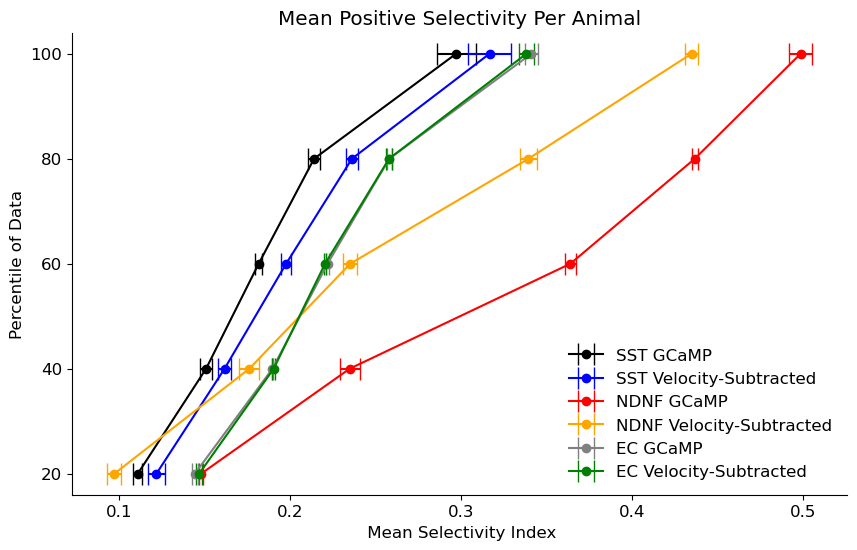

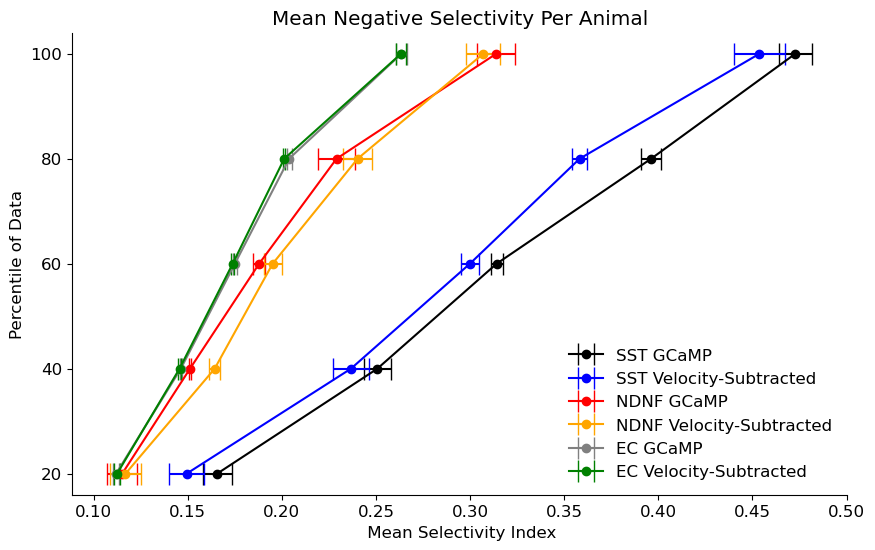

In [7]:
def quantile_split(metric, animal_ID_list, n_bins=10, flatten=False):
   
    if flatten:
        
        flattened_metric = metric.flatten()
        flattened_metric = np.array(flattened_metric)
        
    else:
        flattened_metric=np.array(metric)
        
    sorted_metric= np.argsort(flattened_metric)
    
    animal_ID_list = np.array(animal_ID_list)
    animal_ID_sorted = animal_ID_list[sorted_metric]

  
    quantile_edges = np.quantile(flattened_metric, np.linspace(0, 1, n_bins + 1))
    print(f"quantile_edges {quantile_edges}")
    
    split_metric = []
    split_animal_IDs = []

    animal_ID_list = np.array(animal_ID_list)  
    
    for i in range(n_bins):
        quantile_list = []
        animal_ID_list = []
        for n, value in enumerate(metric):
            if (value >= quantile_edges[i]) & (value < quantile_edges[i + 1]):
                quantile_list.append(value)
                animal_ID_list.append(animal_ID_sorted[n])
                
        split_metric.append(quantile_list)
        split_animal_IDs.append(animal_ID_list)
            

#     for i in range(n_bins):
#         bin_indices = (flattened_metric >= quantile_edges[i]) & (flattened_metric < quantile_edges[i + 1])
#         print(f"bin_indices {bin_indices}")
#         if i == n_bins - 1: 
#             bin_indices |= (flattened_metric == quantile_edges[i + 1])

#         split_metric.append(flattened_metric[bin_indices])
#         split_animal_IDs.append(animal_ID_list[bin_indices])

    return split_metric, split_animal_IDs



split_selectivity_list_SST_raw_positive, split_animal_IDs_list_SST_raw_positive = quantile_split(positive_selectivity_SST_raw, animal_ID_list_SST, n_bins=5, flatten=True)
print(f"len(split_selectivity_list_SST_raw_positive) {split_selectivity_list_SST_raw_positive[1]}")
print(f"len(split_animal_IDs_list_SST_raw_positive) {split_animal_IDs_list_SST_raw_positive[1]}")
split_selectivity_list_NDNF_raw_positive, split_animal_IDs_list_NDNF_raw_positive = quantile_split(positive_selectivity_NDNF_raw, animal_ID_list_NDNF, n_bins=5, flatten=True)
split_selectivity_list_EC_raw_positive, split_animal_IDs_list_EC_raw_positive = quantile_split(positive_selectivity_EC_raw, animal_ID_list_EC, n_bins=5, flatten=True)

split_selectivity_list_SST_raw_negative, split_animal_IDs_list_SST_raw_negative = quantile_split(negative_selectivity_SST_raw, animal_ID_list_SST, n_bins=5, flatten=True)
split_selectivity_list_NDNF_raw_negative, split_animal_IDs_list_NDNF_raw_negative = quantile_split(negative_selectivity_NDNF_raw, animal_ID_list_NDNF, n_bins=5, flatten=True)
split_selectivity_list_EC_raw_negative, split_animal_IDs_list_EC_raw_negative = quantile_split(negative_selectivity_EC_raw, animal_ID_list_EC, n_bins=5, flatten=True)

split_selectivity_list_SST_velocity_positive, split_animal_IDs_list_SST_velocity_positive = quantile_split(positive_selectivity_SST_velocity, animal_ID_list_SST, n_bins=5, flatten=True)
split_selectivity_list_NDNF_velocity_positive, split_animal_IDs_list_NDNF_velocity_positive = quantile_split(positive_selectivity_NDNF_velocity, animal_ID_list_NDNF, n_bins=5, flatten=True)
split_selectivity_list_EC_velocity_positive, split_animal_IDs_list_EC_velocity_positive = quantile_split(positive_selectivity_EC_velocity, animal_ID_list_EC, n_bins=5, flatten=True)

split_selectivity_list_SST_velocity_negative, split_animal_IDs_list_SST_velocity_negative = quantile_split(negative_selectivity_SST_velocity, animal_ID_list_SST, n_bins=5, flatten=True)
split_selectivity_list_NDNF_velocity_negative, split_animal_IDs_list_NDNF_velocity_negative = quantile_split(negative_selectivity_NDNF_velocity, animal_ID_list_NDNF, n_bins=5, flatten=True)
split_selectivity_list_EC_velocity_negative, split_animal_IDs_list_EC_velocity_negative = quantile_split(negative_selectivity_EC_velocity, animal_ID_list_EC, n_bins=5, flatten=True)


from scipy.stats import sem

def get_mean_sem_by_animal(split_animal_IDs_list, split_selectivity_list):
       
    num_parts = len(split_animal_IDs_list)
    mean_values = []
    sem_values = []

    for i in range(num_parts):
        split_animal_IDs = np.array(split_animal_IDs_list[i]) 
        split_values = np.array(split_selectivity_list[i])   
      
        unique_animals = np.unique(split_animal_IDs)
        
        animal_means = []
        
        for animal in unique_animals:
            animal_mask = split_animal_IDs == animal
            animal_values = split_values[animal_mask]
            animal_means.append(np.mean(animal_values))  
        
        mean_values.append(np.mean(animal_means))
        sem_values.append(sem(animal_means))

    return mean_values, sem_values


mean_values_SST_raw_positive, sem_values_SST_raw_positive = get_mean_sem_by_animal(split_animal_IDs_list_SST_raw_positive, split_selectivity_list_SST_raw_positive)
mean_values_NDNF_raw_positive, sem_values_NDNF_raw_positive = get_mean_sem_by_animal(split_animal_IDs_list_NDNF_raw_positive, split_selectivity_list_NDNF_raw_positive)
mean_values_EC_raw_positive, sem_values_EC_raw_positive = get_mean_sem_by_animal(split_animal_IDs_list_EC_raw_positive, split_selectivity_list_EC_raw_positive)

mean_values_SST_raw_negative, sem_values_SST_raw_negative = get_mean_sem_by_animal(split_animal_IDs_list_SST_raw_negative, split_selectivity_list_SST_raw_negative)
mean_values_NDNF_raw_negative, sem_values_NDNF_raw_negative = get_mean_sem_by_animal(split_animal_IDs_list_NDNF_raw_negative, split_selectivity_list_NDNF_raw_negative)
mean_values_EC_raw_negative, sem_values_EC_raw_negative = get_mean_sem_by_animal(split_animal_IDs_list_EC_raw_negative, split_selectivity_list_EC_raw_negative)

mean_values_SST_velocity_positive, sem_values_SST_velocity_positive = get_mean_sem_by_animal(split_animal_IDs_list_SST_velocity_positive, split_selectivity_list_SST_velocity_positive)
mean_values_NDNF_velocity_positive, sem_values_NDNF_velocity_positive = get_mean_sem_by_animal(split_animal_IDs_list_NDNF_velocity_positive, split_selectivity_list_NDNF_velocity_positive)
mean_values_EC_velocity_positive, sem_values_EC_velocity_positive = get_mean_sem_by_animal(split_animal_IDs_list_EC_velocity_positive, split_selectivity_list_EC_velocity_positive)

mean_values_SST_velocity_negative, sem_values_SST_velocity_negative = get_mean_sem_by_animal(split_animal_IDs_list_SST_velocity_negative, split_selectivity_list_SST_velocity_negative)
mean_values_NDNF_velocity_negative, sem_values_NDNF_velocity_negative = get_mean_sem_by_animal(split_animal_IDs_list_NDNF_velocity_negative, split_selectivity_list_NDNF_velocity_negative)
mean_values_EC_velocity_negative, sem_values_EC_velocity_negative = get_mean_sem_by_animal(split_animal_IDs_list_EC_velocity_negative, split_selectivity_list_EC_velocity_negative)

mean_value_list_positive = [mean_values_SST_raw_positive, mean_values_NDNF_raw_positive, mean_values_EC_raw_positive, mean_values_SST_velocity_positive, mean_values_NDNF_velocity_positive, mean_values_EC_velocity_positive]
mean_value_list_negative = [mean_values_SST_raw_negative, mean_values_NDNF_raw_negative, mean_values_EC_raw_negative, mean_values_SST_velocity_negative, mean_values_NDNF_velocity_negative, mean_values_EC_velocity_negative]

sem_value_list_positive = [sem_values_SST_raw_positive, sem_values_NDNF_raw_positive, sem_values_EC_raw_positive, sem_values_SST_velocity_positive, sem_values_NDNF_velocity_positive, sem_values_EC_velocity_positive]
sem_value_list_negative = [sem_values_SST_raw_negative, sem_values_NDNF_raw_negative, sem_values_EC_raw_negative, sem_values_SST_velocity_negative, sem_values_NDNF_velocity_negative, sem_values_EC_velocity_negative]


def plot_mean_with_horizontal_sem_by_animal(mean_value_list, sem_value_list, title, y_title):
    
    bin_centers = np.arange(1, 6)
    
#     y_tick = list(np.linspace(1, 10, 2))
    
    plt.figure(figsize=(10, 6))
    
    plt.errorbar(mean_value_list[0], bin_centers, xerr=sem_value_list[0], fmt='o-', color='black', ecolor='black', capsize=8, label="SST GCaMP") 
    plt.errorbar(mean_value_list[3], bin_centers, xerr=sem_value_list[3], fmt='o-', color='blue', ecolor='blue', capsize=8, label="SST Velocity-Subtracted") 
    plt.errorbar(mean_value_list[1], bin_centers, xerr=sem_value_list[1], fmt='o-', color='red', ecolor='red', capsize=8, label= "NDNF GCaMP")
    plt.errorbar(mean_value_list[4], bin_centers, xerr=sem_value_list[4], fmt='o-', color='orange', ecolor='orange', capsize=8, label="NDNF Velocity-Subtracted")
    plt.errorbar(mean_value_list[2], bin_centers, xerr=sem_value_list[2], fmt='o-', color='gray', ecolor='gray', capsize=8, label= "EC GCaMP")
    plt.errorbar(mean_value_list[5], bin_centers, xerr=sem_value_list[5], fmt='o-', color='green', ecolor='green', capsize=8, label="EC Velocity-Subtracted")
    
    plt.ylabel("Percentile of Data")  
    plt.yticks(ticks=bin_centers, labels=[f"{int(val)}" for val in np.linspace(20, 100, 5)])  
    plt.xlabel(f" Mean {y_title}")  
    plt.title(title)
    plt.legend()

    plt.show()


plot_mean_with_horizontal_sem_by_animal(mean_value_list_positive, sem_value_list_positive, "Mean Positive Selectivity Per Animal", "Selectivity Index")
plot_mean_with_horizontal_sem_by_animal(mean_value_list_negative, sem_value_list_negative, "Mean Negative Selectivity Per Animal", "Selectivity Index")



In [8]:
from scipy.stats import sem

def get_mean_sem_by_animal(split_animal_IDs_list, split_selectivity_list):
       
    num_parts = len(split_animal_IDs_list)
    mean_values = []
    sem_values = []

    for i in range(num_parts):
        split_animal_IDs = np.array(split_animal_IDs_list[i]) 
        split_values = np.array(split_selectivity_list[i])   
      
        unique_animals = np.unique(split_animal_IDs)
        
        animal_means = []
        
        for animal in unique_animals:
            animal_mask = split_animal_IDs == animal
            animal_values = split_values[animal_mask]
            animal_means.append(np.mean(animal_values))  
        
        mean_values.append(np.mean(animal_means))
        sem_values.append(sem(animal_means))

    return mean_values, sem_values

In [9]:
split_argmax_list_SST_raw_positive, split_animal_IDs_list_SST_raw_argmax = quantile_split(argmax_list_SST_raw, animal_ID_list_SST, n_bins=10, flatten=False)

split_argmax_list_NDNF_raw_positive, split_animal_IDs_list_NDNF_raw_argmax = quantile_split(argmax_list_NDNF_raw, animal_ID_list_NDNF, n_bins=10, flatten=False)
split_argmax_list_EC_raw_positive, split_animal_IDs_list_EC_raw_argmax = quantile_split(argmax_list_EC_raw, animal_ID_list_EC, n_bins=10, flatten=False)

split_argmin_list_SST_raw_positive, split_animal_IDs_list_SST_raw_argmin = quantile_split(argmin_list_SST_raw, animal_ID_list_SST, n_bins=10, flatten=False)
split_argmin_list_NDNF_raw_positive, split_animal_IDs_list_NDNF_raw_argmin = quantile_split(argmin_list_NDNF_raw, animal_ID_list_NDNF, n_bins=10, flatten=False)
split_argmin_list_EC_raw_positive, split_animal_IDs_list_EC_raw_argmin = quantile_split(argmin_list_EC_raw, animal_ID_list_EC, n_bins=10, flatten=False)


split_argmax_list_SST_velocity_positive, split_animal_IDs_list_SST_velocity_argmax = quantile_split(argmax_list_SST_velocity, animal_ID_list_SST, n_bins=10, flatten=False)
split_argmax_list_NDNF_velocity_positive, split_animal_IDs_list_NDNF_velocity_argmax = quantile_split(argmax_list_NDNF_velocity, animal_ID_list_NDNF, n_bins=10, flatten=False)
split_argmax_list_EC_velocity_positive, split_animal_IDs_list_EC_velocity_argmax = quantile_split(argmax_list_EC_velocity, animal_ID_list_EC, n_bins=10, flatten=False)

split_argmin_list_SST_velocity_positive, split_animal_IDs_list_SST_velocity_argmin = quantile_split(argmin_list_SST_velocity, animal_ID_list_SST, n_bins=10, flatten=False)
split_argmin_list_NDNF_velocity_positive, split_animal_IDs_list_NDNF_velocity_argmin = quantile_split(argmin_list_NDNF_velocity, animal_ID_list_NDNF, n_bins=10, flatten=False)
split_argmin_list_EC_velocity_positive, split_animal_IDs_list_EC_velocity_argmin = quantile_split(argmin_list_EC_velocity, animal_ID_list_EC, n_bins=10, flatten=False)


quantile_edges [ 0.   2.   4.8  8.  13.8 25.  37.  41.8 44.  46.6 49. ]
quantile_edges [ 7.  21.4 23.8 25.  26.  26.  26.  27.  32.  34.4 43. ]
quantile_edges [ 0.  3.  7. 11. 18. 25. 29. 36. 41. 45. 49.]
quantile_edges [ 0.  22.4 26.  27.  27.  27.  28.  28.  28.  29.6 36. ]
quantile_edges [ 1.   4.8 25.2 26.  27.  32.  38.4 42.6 44.  44.  48. ]
quantile_edges [ 0.  9. 14. 20. 25. 27. 30. 32. 36. 42. 49.]
quantile_edges [ 0.   3.   6.   9.4 12.  25.  26.2 40.4 43.2 47.  49. ]
quantile_edges [ 7.  21.  22.  24.2 25.  26.  26.  27.6 32.  38.  43. ]
quantile_edges [ 0.   3.   8.  12.  18.4 25.  30.  36.  41.  45.  49. ]
quantile_edges [ 0.  20.2 26.  27.  27.  28.  28.4 29.  30.  30.6 42. ]
quantile_edges [ 1.  23.6 26.  27.  28.  29.  30.4 39.6 45.2 47.  49. ]
quantile_edges [ 0.  8. 15. 20. 25. 27. 30. 32. 36. 42. 49.]


quantile_edges [ 0.   4.8 13.8 37.  44.  49. ]
quantile_edges [ 7.  23.8 26.  26.  32.  43. ]
quantile_edges [ 0.  7. 18. 29. 41. 49.]
quantile_edges [ 0. 26. 27. 28. 28. 36.]
quantile_edges [ 1.  25.2 27.  38.4 44.  48. ]
quantile_edges [ 0. 14. 25. 30. 36. 49.]
 split_argmin_list_SST_raw_positive [[25, 22, 22, 18, 19, 6, 23, 10, 25, 6, 0], [26, 26, 26, 26, 26, 26, 26, 26, 26, 26], [27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27], [], [29, 32, 29, 28, 28, 28, 28, 28, 28, 35, 28, 28, 30, 31, 30, 28, 28, 28, 30, 28, 28, 28, 28, 29, 29, 28, 29, 28, 28, 30, 29]]
 split_animal_IDs_list_SST_raw_argmin [['animal_6', 'animal_2', 'animal_2', 'animal_4', 'animal_5', 'animal_3', 'animal_3', 'animal_1', 'animal_4', 'animal_10', 'animal_1'], ['animal_10', 'animal_1', 'animal_5', 'animal_7', 'animal_7', 'animal_2', 'animal_9', 'animal_2', 'animal_2', 'animal_10'], ['animal_5', 'animal_5', 'animal_6', 'animal_6', 'animal_6', 'animal_6', 'animal_6', 'animal_6',

C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


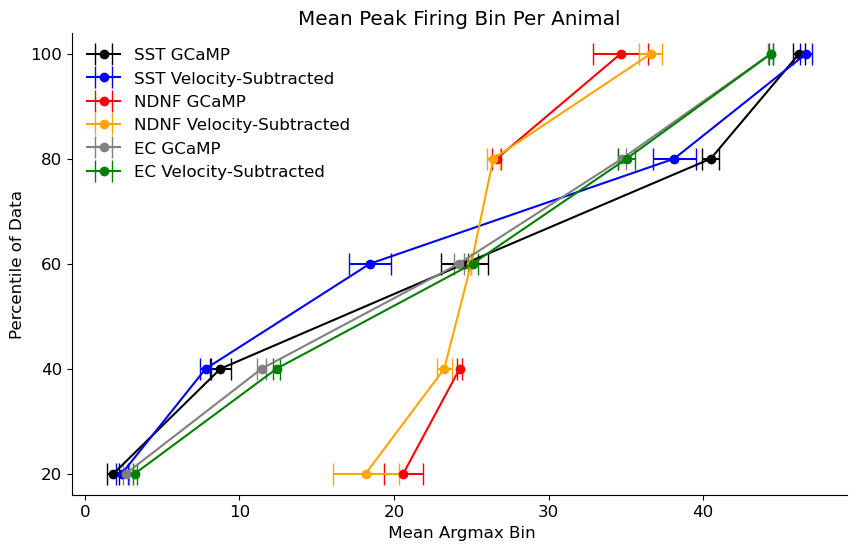

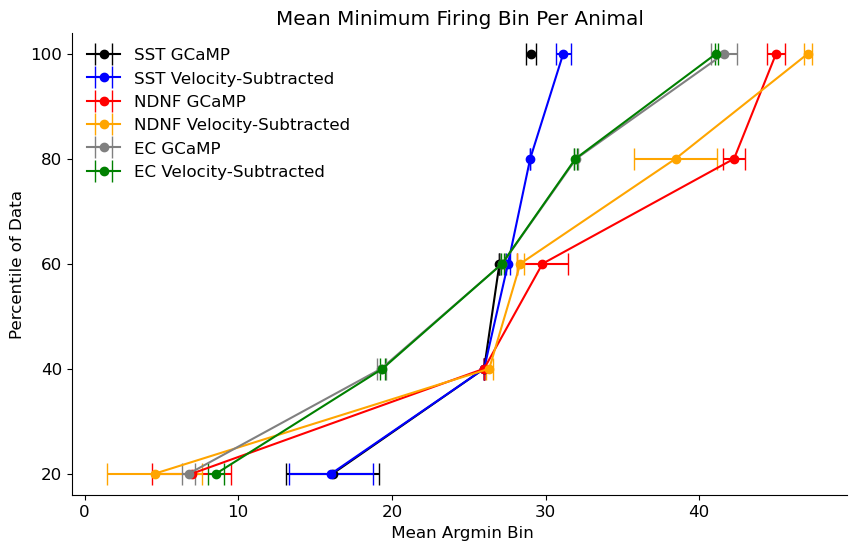

In [10]:
split_argmax_list_SST_raw_positive, split_animal_IDs_list_SST_raw_argmax = quantile_split(argmax_list_SST_raw, animal_ID_list_SST, n_bins=5, flatten=False)
split_argmax_list_NDNF_raw_positive, split_animal_IDs_list_NDNF_raw_argmax = quantile_split(argmax_list_NDNF_raw, animal_ID_list_NDNF, n_bins=5, flatten=False)
split_argmax_list_EC_raw_positive, split_animal_IDs_list_EC_raw_argmax = quantile_split(argmax_list_EC_raw, animal_ID_list_EC, n_bins=5, flatten=False)

split_argmin_list_SST_raw_positive, split_animal_IDs_list_SST_raw_argmin = quantile_split(argmin_list_SST_raw, animal_ID_list_SST, n_bins=5, flatten=False)
split_argmin_list_NDNF_raw_positive, split_animal_IDs_list_NDNF_raw_argmin = quantile_split(argmin_list_NDNF_raw, animal_ID_list_NDNF, n_bins=5, flatten=False)
split_argmin_list_EC_raw_positive, split_animal_IDs_list_EC_raw_argmin = quantile_split(argmin_list_EC_raw, animal_ID_list_EC, n_bins=5, flatten=False)

print(f" split_argmin_list_SST_raw_positive {split_argmin_list_SST_raw_positive}")
print(f" split_animal_IDs_list_SST_raw_argmin {split_animal_IDs_list_SST_raw_argmin}")


split_argmax_list_SST_velocity_positive, split_animal_IDs_list_SST_velocity_argmax = quantile_split(argmax_list_SST_velocity, animal_ID_list_SST, n_bins=5, flatten=False)
split_argmax_list_NDNF_velocity_positive, split_animal_IDs_list_NDNF_velocity_argmax = quantile_split(argmax_list_NDNF_velocity, animal_ID_list_NDNF, n_bins=5, flatten=False)
split_argmax_list_EC_velocity_positive, split_animal_IDs_list_EC_velocity_argmax = quantile_split(argmax_list_EC_velocity, animal_ID_list_EC, n_bins=5, flatten=False)

split_argmin_list_SST_velocity_positive, split_animal_IDs_list_SST_velocity_argmin = quantile_split(argmin_list_SST_velocity, animal_ID_list_SST, n_bins=5, flatten=False)
split_argmin_list_NDNF_velocity_positive, split_animal_IDs_list_NDNF_velocity_argmin = quantile_split(argmin_list_NDNF_velocity, animal_ID_list_NDNF, n_bins=5, flatten=False)
split_argmin_list_EC_velocity_positive, split_animal_IDs_list_EC_velocity_argmin = quantile_split(argmin_list_EC_velocity, animal_ID_list_EC, n_bins=5, flatten=False)


mean_values_SST_raw_argmax, sem_values_SST_raw_argmax = get_mean_sem_by_animal(split_animal_IDs_list_SST_raw_argmax, split_argmax_list_SST_raw_positive)
mean_values_NDNF_raw_argmax, sem_values_NDNF_raw_argmax = get_mean_sem_by_animal(split_animal_IDs_list_NDNF_raw_argmax, split_argmax_list_NDNF_raw_positive)
mean_values_EC_raw_argmax, sem_values_EC_raw_argmax = get_mean_sem_by_animal(split_animal_IDs_list_EC_raw_argmax, split_argmax_list_EC_raw_positive)

mean_values_SST_raw_argmin, sem_values_SST_raw_argmin = get_mean_sem_by_animal(split_animal_IDs_list_SST_raw_argmin, split_argmin_list_SST_raw_positive)
mean_values_NDNF_raw_argmin, sem_values_NDNF_raw_argmin = get_mean_sem_by_animal(split_animal_IDs_list_NDNF_raw_argmin, split_argmin_list_NDNF_raw_positive)
mean_values_EC_raw_argmin, sem_values_EC_raw_argmin = get_mean_sem_by_animal(split_animal_IDs_list_EC_raw_argmin, split_argmin_list_EC_raw_positive)

print(f"mean_values_SST_raw_argmin {mean_values_SST_raw_argmin}")
print(f"sem_values_SST_raw_argmin {sem_values_SST_raw_argmin}")

mean_values_SST_velocity_argmax, sem_values_SST_velocity_argmax = get_mean_sem_by_animal(split_animal_IDs_list_SST_velocity_argmax, split_argmax_list_SST_velocity_positive)
mean_values_NDNF_velocity_argmax, sem_values_NDNF_velocity_argmax = get_mean_sem_by_animal(split_animal_IDs_list_NDNF_velocity_argmax, split_argmax_list_NDNF_velocity_positive)
mean_values_EC_velocity_argmax, sem_values_EC_velocity_argmax = get_mean_sem_by_animal(split_animal_IDs_list_EC_velocity_argmax, split_argmax_list_EC_velocity_positive)

mean_values_SST_velocity_argmin, sem_values_SST_velocity_argmin = get_mean_sem_by_animal(split_animal_IDs_list_SST_velocity_argmin, split_argmin_list_SST_velocity_positive)
mean_values_NDNF_velocity_argmin, sem_values_NDNF_velocity_argmin = get_mean_sem_by_animal(split_animal_IDs_list_NDNF_velocity_argmin, split_argmin_list_NDNF_velocity_positive)
mean_values_EC_velocity_argmin, sem_values_EC_velocity_argmin = get_mean_sem_by_animal(split_animal_IDs_list_EC_velocity_argmin, split_argmin_list_EC_velocity_positive)

mean_value_list_argmax = [mean_values_SST_raw_argmax, mean_values_NDNF_raw_argmax, mean_values_EC_raw_argmax, mean_values_SST_velocity_argmax, mean_values_NDNF_velocity_argmax, mean_values_EC_velocity_argmax]
mean_value_list_argmin = [mean_values_SST_raw_argmin, mean_values_NDNF_raw_argmin, mean_values_EC_raw_argmin, mean_values_SST_velocity_argmin, mean_values_NDNF_velocity_argmin, mean_values_EC_velocity_argmin]

sem_value_list_argmax = [sem_values_SST_raw_argmax, sem_values_NDNF_raw_argmax, sem_values_EC_raw_argmax, sem_values_SST_velocity_argmax, sem_values_NDNF_velocity_argmax, sem_values_EC_velocity_argmax]
sem_value_list_argmin = [sem_values_SST_raw_argmin, sem_values_NDNF_raw_argmin, sem_values_EC_raw_argmin, sem_values_SST_velocity_argmin, sem_values_NDNF_velocity_argmin, sem_values_EC_velocity_argmin]

def plot_mean_with_horizontal_sem_by_animal(mean_value_list, sem_value_list, title, y_title):
    
    bin_centers = np.arange(1, 6)
    
#     y_tick = list(np.linspace(1, 10, 1))
    
    plt.figure(figsize=(10, 6))
    
    plt.errorbar(mean_value_list[0], bin_centers, xerr=sem_value_list[0], fmt='o-', color='black', ecolor='black', capsize=8, label="SST GCaMP") 
    plt.errorbar(mean_value_list[3], bin_centers, xerr=sem_value_list[3], fmt='o-', color='blue', ecolor='blue', capsize=8, label="SST Velocity-Subtracted") 
    plt.errorbar(mean_value_list[1], bin_centers, xerr=sem_value_list[1], fmt='o-', color='red', ecolor='red', capsize=8, label= "NDNF GCaMP")
    plt.errorbar(mean_value_list[4], bin_centers, xerr=sem_value_list[4], fmt='o-', color='orange', ecolor='orange', capsize=8, label="NDNF Velocity-Subtracted")
    plt.errorbar(mean_value_list[2], bin_centers, xerr=sem_value_list[2], fmt='o-', color='gray', ecolor='gray', capsize=8, label= "EC GCaMP")
    plt.errorbar(mean_value_list[5], bin_centers, xerr=sem_value_list[5], fmt='o-', color='green', ecolor='green', capsize=8, label="EC Velocity-Subtracted")
    
    plt.ylabel("Percentile of Data")  
    plt.yticks(ticks=bin_centers, labels=[f"{int(val)}" for val in np.linspace(20, 100, 5)])  
    plt.xlabel(f" Mean {y_title}")  
    plt.title(title)
    plt.legend()

    plt.show()


plot_mean_with_horizontal_sem_by_animal(mean_value_list_argmax, sem_value_list_argmax, "Mean Peak Firing Bin Per Animal", "Argmax Bin")
plot_mean_with_horizontal_sem_by_animal(mean_value_list_argmin, sem_value_list_argmin, "Mean Minimum Firing Bin Per Animal", "Argmin Bin")




In [12]:
  
def quantile_split(metric, animal_ID_list, n_bins=10, flatten=False):
    
    if flatten:
        flattened_metric = metric.flatten()
        flattened_metric = np.array(flattened_metric)
        
    else:
        flattened_metric=np.array(metric)
        
    sorted_metric= np.argsort(flattened_metric)
    
    animal_ID_list = np.array(animal_ID_list)
    animal_ID_sorted = animal_ID_list[sorted_metric]

  
    quantile_edges = np.quantile(flattened_metric, np.linspace(0, 1, n_bins + 1))
    print(f"quantile_edges {quantile_edges}")
    
    split_metric = []
    split_animal_IDs = []

    animal_ID_list = np.array(animal_ID_list)  
    
    for i in range(n_bins):
        quantile_list = []
        animal_ID_list = []
        for n, value in enumerate(metric):
            if (value >= quantile_edges[i]) & (value < quantile_edges[i + 1]):
                quantile_list.append(value)
                animal_ID_list.append(animal_ID_sorted[n])
                
        split_metric.append(quantile_list)
        split_animal_IDs.append(animal_ID_list)
            

#     for i in range(n_bins):
#         bin_indices = (flattened_metric >= quantile_edges[i]) & (flattened_metric < quantile_edges[i + 1])
#         print(f"bin_indices {bin_indices}")
#         if i == n_bins - 1: 
#             bin_indices |= (flattened_metric == quantile_edges[i + 1])

#         split_metric.append(flattened_metric[bin_indices])
#         split_animal_IDs.append(animal_ID_list[bin_indices])

    return split_metric, split_animal_IDs

# split_argmax_list_SST_raw_positive, split_animal_IDs_list_SST_raw_argmax = split_by_animal(argmax_list_SST_raw, animal_ID_list_SST, n_bins=5, flatten=False)


In [13]:
print(f"animal_ID_list_SST {animal_ID_list_SST}")
print(f"argmax_list_SST_raw {argmax_list_SST_raw}")

animal_ID_list_SST ['animal_1', 'animal_1', 'animal_1', 'animal_1', 'animal_1', 'animal_2', 'animal_2', 'animal_2', 'animal_2', 'animal_2', 'animal_2', 'animal_2', 'animal_2', 'animal_2', 'animal_2', 'animal_2', 'animal_2', 'animal_2', 'animal_2', 'animal_2', 'animal_3', 'animal_3', 'animal_3', 'animal_3', 'animal_3', 'animal_3', 'animal_4', 'animal_4', 'animal_4', 'animal_4', 'animal_5', 'animal_5', 'animal_5', 'animal_5', 'animal_5', 'animal_5', 'animal_5', 'animal_5', 'animal_5', 'animal_5', 'animal_5', 'animal_5', 'animal_5', 'animal_6', 'animal_6', 'animal_6', 'animal_6', 'animal_6', 'animal_6', 'animal_6', 'animal_6', 'animal_6', 'animal_6', 'animal_6', 'animal_6', 'animal_6', 'animal_7', 'animal_7', 'animal_7', 'animal_8', 'animal_8', 'animal_8', 'animal_9', 'animal_9', 'animal_9', 'animal_10', 'animal_10', 'animal_10', 'animal_10', 'animal_10', 'animal_10', 'animal_10', 'animal_10', 'animal_10', 'animal_10']
argmax_list_SST_raw [23, 48, 25, 15, 11, 49, 8, 46, 12, 5, 2, 5, 38, 2

In [14]:
from collections import defaultdict

# Initialize a dictionary to hold lists for each animal
animal_to_values = defaultdict(list)

# Iterate through the animal IDs and corresponding values
for animal, value in zip(animal_ID_list_SST, argmax_list_SST_raw):
    animal_to_values[animal].append(value)

# Convert the defaultdict to a regular dictionary (optional)
animal_to_values = dict(animal_to_values)

# Print the result
for animal, values in animal_to_values.items():
    print(f"{animal}: {values}")


animal_1: [23, 48, 25, 15, 11]
animal_2: [49, 8, 46, 12, 5, 2, 5, 38, 25, 8, 7, 6, 5, 6, 25]
animal_3: [11, 42, 44, 45, 18, 18]
animal_4: [47, 42, 48, 49]
animal_5: [0, 3, 2, 0, 12, 43, 27, 33, 4, 49, 47, 33, 2]
animal_6: [2, 40, 41, 46, 2, 42, 37, 37, 46, 1, 8, 4, 0]
animal_7: [48, 39, 44]
animal_8: [42, 26, 46]
animal_9: [42, 25, 44]
animal_10: [12, 2, 3, 7, 37, 4, 46, 25, 25, 41]


In [43]:
print(f"argmax_list_SST_velocity {argmax_list_SST_velocity}")
print(argmax_list_SST_velocity.type)

argmax_list_SST_velocity [23, 48, 25, 15, 11, 49, 8, 46, 12, 6, 2, 12, 38, 25, 11, 7, 6, 7, 12, 25, 11, 42, 47, 45, 18, 19, 47, 42, 47, 49, 0, 3, 2, 0, 12, 43, 28, 33, 4, 49, 47, 33, 2, 8, 25, 25, 41, 8, 42, 35, 37, 48, 25, 9, 4, 0, 48, 37, 46, 6, 20, 4, 42, 25, 44, 12, 2, 3, 3, 41, 7, 46, 25, 25, 41]


AttributeError: 'list' object has no attribute 'type'

In [ ]:
n_bins = 5
edges_list = []
sep_dict = {}  # Dictionary to store quantile-separated values for each animal

for key, value in animal_to_values.items():
    # Compute quantile edges for the current animal
    animal_edges = np.quantile(value, np.linspace(0, 1, n_bins + 1))
    edges_list.append(animal_edges)
    
    # Create a list of lists to store values for each quantile
    quantile_lists = [[] for _ in range(n_bins)]
    
    # Assign each value to the appropriate quantile
    for max_bin in value:
        for i in range(n_bins):  # Iterate over the bins
            if (max_bin >= animal_edges[i]) & (max_bin < animal_edges[i + 1]):
                quantile_lists[i].append(max_bin)
                break  # Stop checking once it's assigned to a quantile

    # Store the quantile-separated lists in the dictionary for the current animal
    sep_dict[key] = quantile_lists

quints_dict = {}
    
for key, quantiles in sep_dict.items():
    for i in range(n_bins):
        quints_dict[i] = [quantiles[i]]
    
    
for key, vaue in quints_dict.items():
    print(f"key quints_dict {key}")
    print(f"value quints_dict {value}")

# quantiles_dict = {}
# for key, quantiles in sep_dict.items():
#     print(f"sep_dict {key}:")
#     print(quantiles)
#     n=0
#     if n <= len(sep_dict):
#         for i in range(n_bins):
#             quantiles_dict[i] = quantiles[n]
#             n+=1


    
    
print(f"quantiles_dict {quantiles_dict}")


# quantiles_grouped = [[] for _ in range(n_bins)]

# # Iterate through the dictionary
# for animal, quantiles in sep_dict.items():
#     for i, quantile in enumerate(quantiles):
#         quantiles_grouped[i].append(quantile)  # Append each quantile to the corresponding group

# # Print the results
# for i, group in enumerate(quantiles_grouped):
#     print(f"Quantile {i + 1}: {group}")
    
    
    
#     quantile_dict = {}
#     for i in range(n_bins):
#         items= [q[i] if q else None for q in quantiles]  
#         quantile_dict[i] = items
#     for i, quant_list in enumerate(quantiles):
#         quantile_dict[i] = quant_list[i]
#     quantile_animal_dict[key] = quantile_dict
        
# for key, value in quantile_dict.items():
#     for key2, subdict in value.items():
#         print(key2)
#         print(subdict)
        
    
    
# # Print the result
# for key, quantiles in sep_dict.items():
#     print(f"{key}:")
#     for i, q_list in enumerate(quantiles):
#         print(f"  Quantile {i + 1}: {q_list}")
        


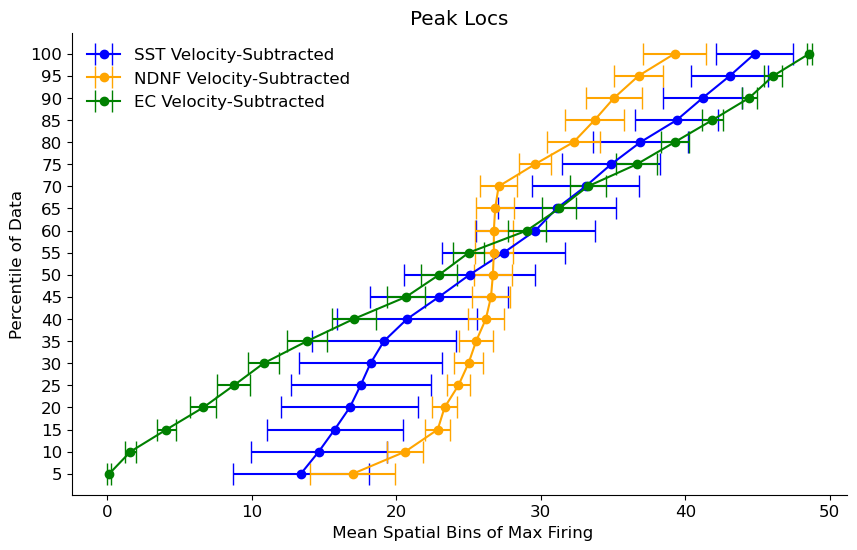

sem_quantiles_SST [4.720593183065026, 4.696922137136921, 4.710364595871404, 4.740083393962331, 4.842153603877691, 4.92392992157445, 4.963176312964652, 4.857149398259056, 4.75675026990002, 4.533660198144957, 4.26169435567163, 4.116575507119623, 4.075735917438476, 3.6808240074691465, 3.393037110175032, 3.2559938336666647, 2.883884441804874, 2.712082333137667, 2.6561719273193187, 2.6563132345414386]


In [87]:

def get_quantiles_for_cdf(animal_ID_list, values_list, n_bins=None):
    
    animal_to_values = defaultdict(list)

    for animal, value in zip(animal_ID_list, values_list):
        animal_to_values[animal].append(value)


    animal_to_values = dict(animal_to_values)

    edges_list = []
    sep_dict = {}  

    for key, value in animal_to_values.items():
        animal_edges = np.quantile(value, np.linspace(0, 1, n_bins))
        edges_list.append(animal_edges)

    stacked_edges = np.vstack(edges_list)

    mean_list = []
    sem_list = []

    for i in range(stacked_edges.shape[1]):
        column = stacked_edges[:, i]
        mean_list.append(np.mean(column))
        sem_list.append((np.std(column)/np.sqrt(len(column))))
        
    return mean_list, sem_list


mean_quantiles_SST, sem_quantiles_SST = get_quantiles_for_cdf(animal_ID_list_SST, argmax_list_SST_velocity, n_bins=20)

mean_quantiles_NDNF, sem_quantiles_NDNF = get_quantiles_for_cdf(animal_ID_list_NDNF, argmax_list_NDNF_velocity, n_bins=20)

mean_quantiles_EC, sem_quantiles_EC = get_quantiles_for_cdf(animal_ID_list_EC, argmax_list_EC_velocity, n_bins=20)


mean_quantiles_list = [mean_quantiles_SST, mean_quantiles_NDNF, mean_quantiles_EC]

sem_quantiles_list = [sem_quantiles_SST, sem_quantiles_NDNF, sem_quantiles_EC]

plot_mean_with_horizontal_sem_by_animal(mean_quantiles_list, sem_quantiles_list, "Peak Locs", "Spatial Bins of Max Firing", n_bins=20)




sep_dict key animal_1:
sep_dict value [[11], [15], [23], [25], []]:
sep_dict key animal_2:
sep_dict value [[6, 2, 6], [8, 7, 7], [11], [12, 12, 25, 12, 25], [46, 38]]:
sep_dict key animal_3:
sep_dict value [[11], [18], [19], [42], [45]]:
sep_dict key animal_4:
sep_dict value [[42], [], [], [47, 47], []]:
sep_dict key animal_5:
sep_dict value [[0, 0], [3, 2, 2], [12, 28, 4], [33, 33], [43, 47]]:
sep_dict key animal_6:
sep_dict value [[4, 0], [8, 8, 9], [25, 25, 25], [35, 37], [41, 42]]:
sep_dict key animal_7:
sep_dict value [[37], [], [46], [], []]:
sep_dict key animal_8:
sep_dict value [[4], [], [6], [], []]:
sep_dict key animal_9:
sep_dict value [[25], [], [42], [], []]:
sep_dict key animal_10:
sep_dict value [[2], [3, 3, 7], [12], [25, 25], [41, 41]]:
sep_dict key animal_1:
sep_dict value [[7, 21], [22, 22, 22], [], [24, 24, 24, 25, 24, 36], [38, 38]]:
sep_dict key animal_2:
sep_dict value [[21, 21, 20], [25], [], [26, 26, 26, 26, 26, 26, 26], [28, 32]]:
sep_dict key animal_3:
sep_di

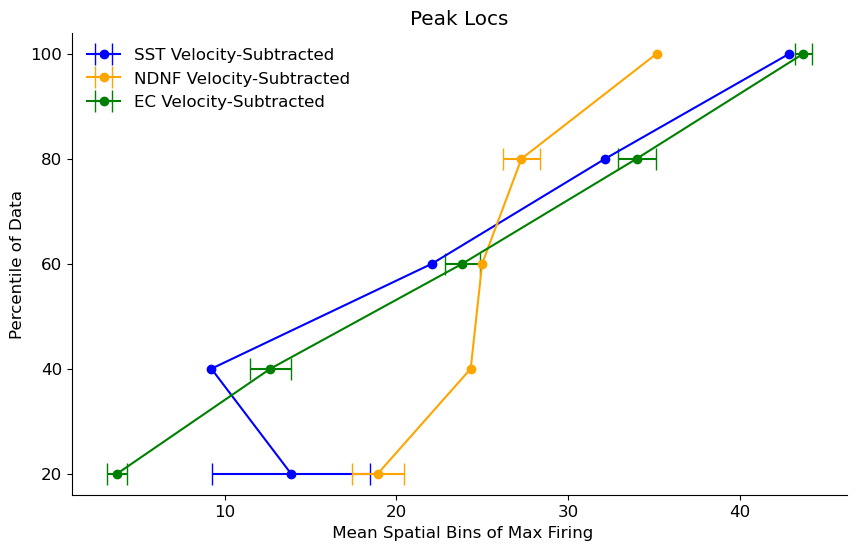

In [69]:


def get_quantiles_for_cdf(animal_ID_list, values_list, n_bins=5):
    
    animal_to_values = defaultdict(list)
    

    for animal, value in zip(animal_ID_list, values_list):
        animal_to_values[animal].append(value)


    animal_to_values = dict(animal_to_values)

    edges_list = []
    sep_dict = {}  

    for key, value in animal_to_values.items():
        animal_edges = np.quantile(value, np.linspace(0, 1, n_bins + 1))
        edges_list.append(animal_edges)

        quantile_lists = [[] for _ in range(n_bins)]

        for max_bin in value:
            for i in range(n_bins):  
                if (max_bin >= animal_edges[i]) & (max_bin < animal_edges[i + 1]):
                    quantile_lists[i].append(max_bin)
                    break  

        sep_dict[key] = quantile_lists

    quints_dict = {i: [] for i in range(n_bins)}

    for key, quantiles in sep_dict.items():
        print(f"sep_dict key {key}:")
        print(f"sep_dict value {quantiles}:")
        for i in range(n_bins):
            quints_dict[i].append(quantiles[i])  

    mean_quantiles = []
    sem_quantiles = []

    mean_quints_dict = {}

    for key, value in quints_dict.items():
        mean_value = []
        for i in value:
            mean_value.append(np.mean(i))
        mean_quints_dict[key] = mean_value

    for key, value in mean_quints_dict.items():
        mean_quantiles.append(np.nanmean(value))
        sem_quantiles.append((np.std(value)/np.sqrt(len(value))))
        
    return mean_quantiles, sem_quantiles

def plot_mean_with_horizontal_sem_by_animal(mean_quantiles_list, sem_quantiles_list, title=None, x_title=None, n_bins=None):
    bin_centers = np.arange(1, n_bins+1)
    
    plt.figure(figsize=(10, 6))
    
    plt.errorbar(mean_quantiles_list[0], bin_centers, xerr=sem_quantiles_list[0], fmt='o-', color='blue', ecolor='blue', capsize=8, label="SST Velocity-Subtracted") 
    plt.errorbar(mean_quantiles_list[1], bin_centers, xerr=sem_quantiles_list[1], fmt='o-', color='orange', ecolor='orange', capsize=8, label="NDNF Velocity-Subtracted") 
    plt.errorbar(mean_quantiles_list[2], bin_centers, xerr=sem_quantiles_list[2], fmt='o-', color='green', ecolor='green', capsize=8, label= "EC Velocity-Subtracted")
   
    plt.ylabel("Percentile of Data")  
    plt.yticks(ticks=bin_centers, labels=[f"{int(val)}" for val in np.linspace((100/n_bins), 100, n_bins)])  
    plt.xlabel(f" Mean {x_title}")  
    plt.title(title)
    plt.legend()

    plt.show()



mean_quantiles_SST, sem_quantiles_SST = get_quantiles_for_cdf(animal_ID_list_SST, argmax_list_SST_velocity, n_bins=5)

mean_quantiles_NDNF, sem_quantiles_NDNF = get_quantiles_for_cdf(animal_ID_list_NDNF, argmax_list_NDNF_velocity, n_bins=5)

mean_quantiles_EC, sem_quantiles_EC = get_quantiles_for_cdf(animal_ID_list_EC, argmax_list_EC_velocity, n_bins=5)


print(f"Mean quantiles argmax (SST): {mean_quantiles_SST} (len: {len(mean_quantiles_SST)})")
print(f"Mean quantiles argmax (NDNF): {mean_quantiles_NDNF} (len: {len(mean_quantiles_NDNF)})")
print(f"Mean quantiles argmax (EC): {mean_quantiles_EC} (len: {len(mean_quantiles_EC)})")


mean_quantiles_list = [mean_quantiles_SST, mean_quantiles_NDNF, mean_quantiles_EC]

sem_quantiles_list = [sem_quantiles_SST, sem_quantiles_NDNF, sem_quantiles_EC]

plot_mean_with_horizontal_sem_by_animal(mean_quantiles_list, sem_quantiles_list, "Peak Locs", "Spatial Bins of Max Firing", n_bins=5)



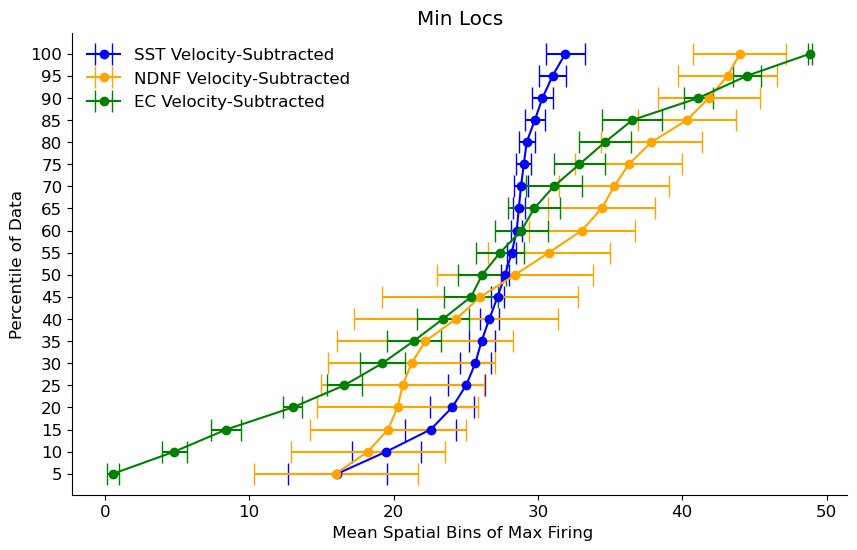

In [89]:
mean_quantiles_SST, sem_quantiles_SST = get_quantiles_for_cdf(animal_ID_list_SST, argmin_list_SST_velocity, n_bins=20)

mean_quantiles_NDNF, sem_quantiles_NDNF = get_quantiles_for_cdf(animal_ID_list_NDNF, argmin_list_NDNF_velocity, n_bins=20)

mean_quantiles_EC, sem_quantiles_EC = get_quantiles_for_cdf(animal_ID_list_EC, argmin_list_EC_velocity, n_bins=20)

mean_quantiles_list = [mean_quantiles_SST, mean_quantiles_NDNF, mean_quantiles_EC]

sem_quantiles_list = [sem_quantiles_SST, sem_quantiles_NDNF, sem_quantiles_EC]

plot_mean_with_horizontal_sem_by_animal(mean_quantiles_list, sem_quantiles_list, "Min Locs", "Spatial Bins of Max Firing", n_bins=20)


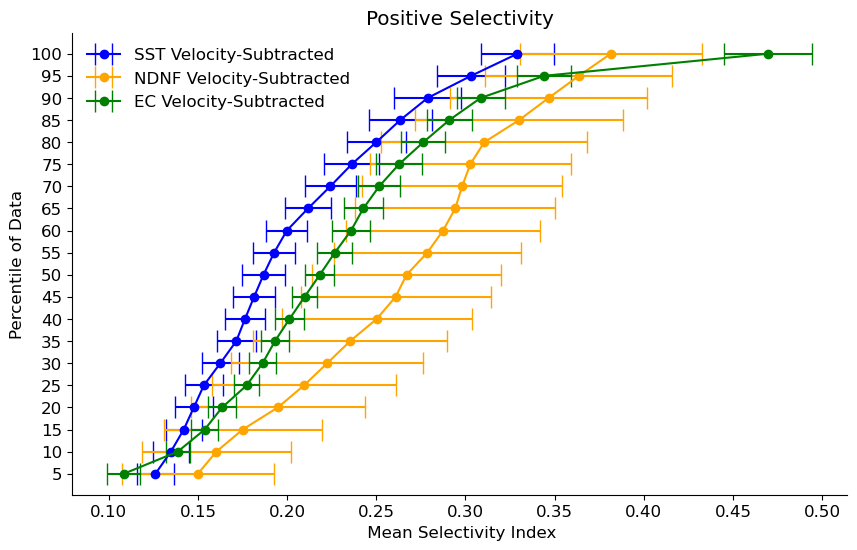

In [90]:
mean_quantiles_SST, sem_quantiles_SST = get_quantiles_for_cdf(animal_ID_list_SST, positive_selectivity_SST_velocity, n_bins=20)

mean_quantiles_NDNF, sem_quantiles_NDNF = get_quantiles_for_cdf(animal_ID_list_NDNF, positive_selectivity_NDNF_velocity, n_bins=20)

mean_quantiles_EC, sem_quantiles_EC = get_quantiles_for_cdf(animal_ID_list_EC, positive_selectivity_EC_velocity, n_bins=20)

mean_quantiles_list = [mean_quantiles_SST, mean_quantiles_NDNF, mean_quantiles_EC]

sem_quantiles_list = [sem_quantiles_SST, sem_quantiles_NDNF, sem_quantiles_EC]

plot_mean_with_horizontal_sem_by_animal(mean_quantiles_list, sem_quantiles_list, "Positive Selectivity", "Selectivity Index", n_bins=20)


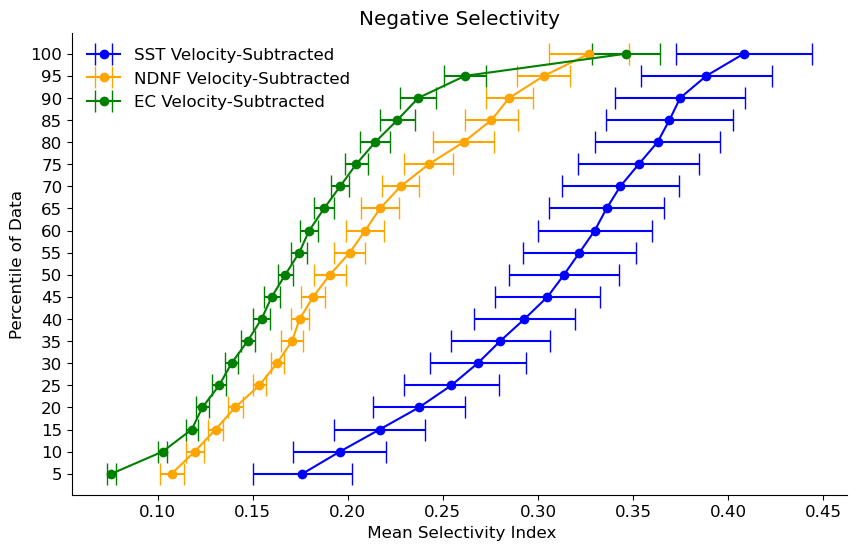

In [91]:
mean_quantiles_SST, sem_quantiles_SST = get_quantiles_for_cdf(animal_ID_list_SST, negative_selectivity_SST_velocity, n_bins=20)

mean_quantiles_NDNF, sem_quantiles_NDNF = get_quantiles_for_cdf(animal_ID_list_NDNF, negative_selectivity_NDNF_velocity, n_bins=20)

mean_quantiles_EC, sem_quantiles_EC = get_quantiles_for_cdf(animal_ID_list_EC, negative_selectivity_EC_velocity, n_bins=20)

mean_quantiles_list = [mean_quantiles_SST, mean_quantiles_NDNF, mean_quantiles_EC]

sem_quantiles_list = [sem_quantiles_SST, sem_quantiles_NDNF, sem_quantiles_EC]

plot_mean_with_horizontal_sem_by_animal(mean_quantiles_list, sem_quantiles_list, "Negative Selectivity", "Selectivity Index", n_bins=20)




In [ ]:
def get_min_max_loc_difference_subplots(titles, datasets):
    
    bin_edges = np.arange(0, 51, 5)
    bin_centers = bin_edges[:-1] + 2.5
    bin_labels = [f"{start}-{start + 4}" for start in bin_edges[:-1]]

    fig, axs = plt.subplots(2, 4, figsize=(25,12))

    # Adjust spacing between subplots
    plt.subplots_adjust(hspace=0.4, wspace=0.5)

    # Unified bin settings for clarity
    y_max = 0.15
    x_min, x_max = 0, 45



    for ax, title, data in zip(axs.flat, titles, datasets):
        ax.bar(bin_centers, data, width=5, align='center', edgecolor='k', color='blue', alpha=0.7)
        ax.set_title(title, fontsize=12)
        ax.set_ylim(-y_max, y_max)
        ax.set_xlim(x_min, x_max)
        ax.set_xlabel("Position Bin", fontsize=10)
        ax.set_ylabel("Fraction of Total Cells", fontsize=10)
        ax.grid(axis='y', linestyle='--', alpha=0.7)


    # Show the final plot
    plt.show()
    